# 03 · Cross-validation, recall selection and evaluation

Results below are read from measured artifacts. The Hugging Face workflow compares XGBoost with and without random oversampling, using expanding chronological CV windows on a 60,000-row training sample and full-partition refits. Model depth and sampling ratio are tuned by average precision. Validation F2 selects the model and threshold before test evaluation.

In [1]:
from pathlib import Path
import json, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
metadata = json.loads(Path('models/model_metadata.json').read_text())
RUN_TRAINING = False
if RUN_TRAINING:
    from src.train import train
    from threadpoolctl import threadpool_limits
    with threadpool_limits(limits=4):
        train(Path('data/raw') / metadata['dataset']['file'], Path('models'), target=metadata['dataset']['target'],
              seed=metadata['training']['seed'], profile_name=metadata['training']['profile'],
              minimum_recall=metadata.get('minimum_validation_recall'), candidate_names=metadata['training']['requested_candidates'],
              split_strategy=metadata['dataset']['split_strategy'])
    metadata = json.loads(Path('models/model_metadata.json').read_text())
print(metadata['selection_rule'])
print(metadata['training'])


Matplotlib is building the font cache; this may take a moment.


Highest validation F2 (beta=2) among requested candidates; recall then average precision break ties. CV tunes parameters by average precision. Threshold maximizes validation F2. No test metrics enter selection.
{'seed': 42, 'profile': 'recall', 'requested_candidates': ['XGBoost', 'XGBoost · random oversampling'], 'cv_folds': 3, 'cv_strategy': 'expanding chronological windows', 'tuning_rows': 60000, 'full_training_rows': 629145, 'duration_seconds': 161.55, 'duplicates_removed': 0}


## CV and validation
Timestamps tied at boundaries never appear on both sides of a chronological training/validation boundary. Preprocessing and oversampling are fitted in training only. Few positive examples and recurring customers still limit generalization claims.

In [2]:
display(pd.DataFrame([{'model': row['name'], 'CV AP': row['cv_pr_auc'], 'CV std': row['cv_std'],
                      'validation AP': row['validation']['pr_auc'], 'validation recall': row['validation']['recall'],
                      'validation precision': row['validation']['precision'], 'validation F2': row['validation']['f2'],
                      'threshold': row['threshold'], 'selected': row['selected']} for row in metadata['comparison']]))


,model,CV AP,CV std,validation AP,validation recall,validation precision,validation F2,threshold,selected
0,XGBoost,0.730269,0.028859,0.806978,0.785030,0.678195,0.761053,0.174504,False
1,XGBoost · random oversampling,0.768838,0.019837,0.840415,0.818973,0.739780,0.801806,0.795771,True


## Frozen selection, then later test transactions
There is no refit on validation or test. Average precision is reported as PR-AUC; it is not trapezoidal integration. Results from the older ULB experiment belong to a different dataset and are not directly comparable.

In [3]:
print('Selected:', metadata['model_name'], metadata['model_version'])
print('Threshold:', metadata['selected_threshold'])
display(pd.DataFrame([{'model': row['name'], **{key:value for key,value in row['test'].items() if key != 'confusion_matrix'}} for row in metadata['comparison']]))
display(pd.DataFrame(metadata['metrics']['confusion_matrix'], index=['Actual legitimate','Actual fraud'], columns=['Predicted legitimate','Predicted fraud']))


Selected: XGBoost · random oversampling hf-20260910T092649Z
Threshold: 0.7957711219787598


,model,accuracy,precision,recall,f1,f2,roc_auc,pr_auc
0,XGBoost,0.996490,0.647867,0.782533,0.708861,0.751300,0.992095,0.796087
1,XGBoost · random oversampling,0.996953,0.693130,0.793013,0.739715,0.770798,0.995821,0.804547


,Predicted legitimate,Predicted fraud
Actual legitimate,208168,402
Actual fraud,237,908


## Precision–recall, ROC and threshold trade-offs
Lower thresholds can catch more fraud and create more reviews. F2 weights recall more than precision. A configurable minimum validation recall is available, but does not guarantee future recall. Risk bands are separate presentation categories.

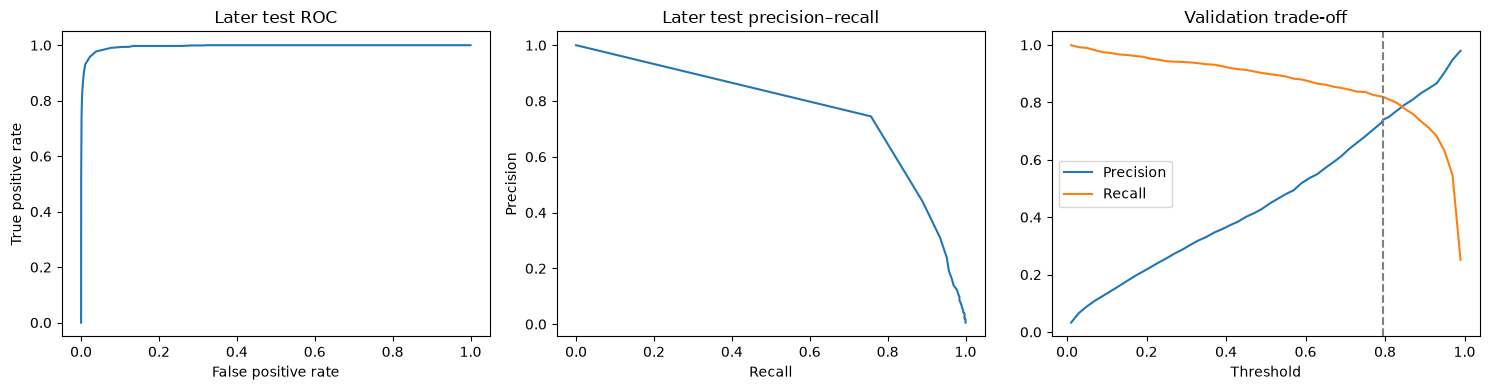

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
roc = pd.DataFrame(metadata['curves']['roc'])
pr = pd.DataFrame(metadata['curves']['precision_recall'])
thresholds = pd.DataFrame(metadata['threshold_curve'])
axes[0].plot(roc.fpr, roc.tpr)
axes[0].set(xlabel='False positive rate', ylabel='True positive rate', title='Later test ROC')
axes[1].plot(pr.recall, pr.precision)
axes[1].set(xlabel='Recall', ylabel='Precision', title='Later test precision–recall')
axes[2].plot(thresholds.threshold, thresholds.precision, label='Precision')
axes[2].plot(thresholds.threshold, thresholds.recall, label='Recall')
axes[2].axvline(metadata['selected_threshold'], linestyle='--', color='grey')
axes[2].legend()
axes[2].set(xlabel='Threshold', title='Validation trade-off')
plt.tight_layout()
plt.show()


## Explainability and limits
Global importance and local sensitivity describe associations, not reasons that prove fraud. Scores are uncalibrated. Validation and test customers may recur, and the dataset card provides limited collection provenance.

In [5]:
print(metadata['importance_method'])
display(pd.DataFrame(metadata['feature_importance']).head(15))
print(metadata['probability_note'])
print(metadata['dataset'].get('provenance_note'))


model-native feature importance (global; not causal)


,feature,importance
0,Amount_log1p,0.139938
1,Amount,0.110686
2,category_gas_transport,0.082549
3,Time_phase_cos,0.054460
4,category_grocery_net,0.041199
5,category_food_dining,0.035199
6,category_home,0.033596
7,category_shopping_net,0.032983
8,category_entertainment,0.032544
9,category_travel,0.031928


Model scores are not calibrated probabilities of real-world fraud. Class weighting/resampling and distribution shift affect calibration.
Public benchmark. The dataset card does not document its collection methodology.
